In [22]:
import pandas as pd
df = pd.read_csv("dataset.csv", encoding='latin1')
stress_cols = ["Q1","Q6","Q8","Q11","Q12","Q14","Q18"]
df["stress_score"] = df[stress_cols].sum(axis=1) * 2
df = df[df["stress_score"] != 0]


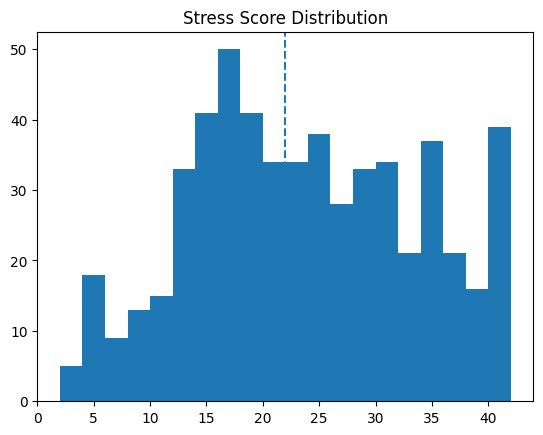

In [44]:
import matplotlib.pyplot as plt

plt.hist(df["stress_score"], bins=20)
plt.axvline(df["stress_score"].median(), linestyle='--')
plt.title("Stress Score Distribution")
plt.show()

In [24]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
df["cluster"] = kmeans.fit_predict(df[["stress_score"]])

# Find boundary between clusters
centers = sorted(kmeans.cluster_centers_.flatten())
threshold = sum(centers) / 2

print("Cluster centers:", centers)
print("Suggested threshold:", threshold)

df = df.drop("cluster", axis=1)
df["stress_label"] = df["stress_score"].apply(lambda x: "high" if x > threshold else "low")

df.head()

Cluster centers: [np.float64(14.7645051194539), np.float64(31.745318352059908)]
Suggested threshold: 23.254911735756906


,I Agree to participate in the research project under the conditions described above,The name of your institution\n,The name of your program of study\n,Your current class level is,Your gender,Your current age,Living with family?,Are you happy with your academic Condition?,Your CGPA,Are you addicted to any drugs?,...,TQ3,TQ4,TQ5,TQ6,TQ7,TQ8,TQ9,TQ10,stress_score,stress_label
0,"Yes, I agree to participate,",EDU,CSE,Freshman (Undergrad),Female,> 25,Yes,Yes,3.01-3.50,No,...,4,7,7,7,7,5,1,1,24,high
1,"Yes, I agree to participate,",EDU,CSE,Senior (Undergrad),Male,21-25,Yes,Yes,3.01-3.50,No,...,2,7,5,4,7,5,1,5,30,high
3,"Yes, I agree to participate,",East Delta University,CSE,Senior (Undergrad),Female,21-25,Yes,Yes,> 3.50,No,...,3,4,6,4,6,5,6,1,14,low
4,"Yes, I agree to participate,",East Delta University,BSC in CSE,Senior (Undergrad),Male,21-25,Yes,Yes,> 3.50,No,...,6,6,5,5,5,5,3,3,18,low
5,"Yes, I agree to participate,",East Delta University,CSE,Junior (Undergrad),Female,21-25,Yes,Yes,> 3.50,No,...,6,1,7,7,7,5,6,7,22,low


In [25]:
def reverse(x):
    return 8 - x
df["Extraversion"] = (df["TQ1"] + reverse(df["TQ6"])) / 2
df["Agreeableness"] = (reverse(df["TQ2"]) + df["TQ7"]) / 2
df["Conscientiousness"] = (df["TQ3"] + reverse(df["TQ8"])) / 2
df["Emotional_Stability"] = (reverse(df["TQ4"]) + df["TQ9"]) / 2
df["Openness"] = (df["TQ5"] + reverse(df["TQ10"])) / 2
df = df.drop(columns=["TQ1","TQ2","TQ3","TQ4","TQ5","TQ6","TQ7","TQ8","TQ9","TQ10"])
df.head()

,I Agree to participate in the research project under the conditions described above,The name of your institution\n,The name of your program of study\n,Your current class level is,Your gender,Your current age,Living with family?,Are you happy with your academic Condition?,Your CGPA,Are you addicted to any drugs?,...,Q12,Q14,Q18,stress_score,stress_label,Extraversion,Agreeableness,Conscientiousness,Emotional_Stability,Openness
0,"Yes, I agree to participate,",EDU,CSE,Freshman (Undergrad),Female,> 25,Yes,Yes,3.01-3.50,No,...,1,2,3,24,high,1.0,5.0,3.5,1.0,7.0
1,"Yes, I agree to participate,",EDU,CSE,Senior (Undergrad),Male,21-25,Yes,Yes,3.01-3.50,No,...,3,3,2,30,high,5.0,5.0,2.5,1.0,4.0
3,"Yes, I agree to participate,",East Delta University,CSE,Senior (Undergrad),Female,21-25,Yes,Yes,> 3.50,No,...,2,1,1,14,low,2.5,6.5,3.0,5.0,6.5
4,"Yes, I agree to participate,",East Delta University,BSC in CSE,Senior (Undergrad),Male,21-25,Yes,Yes,> 3.50,No,...,0,0,0,18,low,2.5,4.0,4.5,2.5,5.0
5,"Yes, I agree to participate,",East Delta University,CSE,Junior (Undergrad),Female,21-25,Yes,Yes,> 3.50,No,...,2,0,1,22,low,1.5,7.0,4.5,6.5,4.0


max of tipi 7
max of dass21 stress 42

In [26]:
column_names = df.columns.tolist()
df = df.drop([column_names[0], column_names[1]], axis=1)
df.head()

,The name of your program of study\n,Your current class level is,Your gender,Your current age,Living with family?,Are you happy with your academic Condition?,Your CGPA,Are you addicted to any drugs?,Are you in a relationship?,Did you have a recent breakup?,...,Q12,Q14,Q18,stress_score,stress_label,Extraversion,Agreeableness,Conscientiousness,Emotional_Stability,Openness
0,CSE,Freshman (Undergrad),Female,> 25,Yes,Yes,3.01-3.50,No,Yes,Yes,...,1,2,3,24,high,1.0,5.0,3.5,1.0,7.0
1,CSE,Senior (Undergrad),Male,21-25,Yes,Yes,3.01-3.50,No,Yes,No,...,3,3,2,30,high,5.0,5.0,2.5,1.0,4.0
3,CSE,Senior (Undergrad),Female,21-25,Yes,Yes,> 3.50,No,No,No,...,2,1,1,14,low,2.5,6.5,3.0,5.0,6.5
4,BSC in CSE,Senior (Undergrad),Male,21-25,Yes,Yes,> 3.50,No,No,No,...,0,0,0,18,low,2.5,4.0,4.5,2.5,5.0
5,CSE,Junior (Undergrad),Female,21-25,Yes,Yes,> 3.50,No,Yes,No,...,2,0,1,22,low,1.5,7.0,4.5,6.5,4.0


In [27]:
def map_program(x):
    x = str(x).lower().strip()
    if any(k in x for k in ["cse", "computer", "it", "software", "information technology"]):
        return "CSE"
    elif any(k in x for k in ["eee", "electrical", "electronics", "electronic", "ece"]):
        return "EEE"
    elif any(k in x for k in ["mba", "bba", "management", "business", "hrm"]):
        return "Management"
    elif any(k in x for k in ["mbbs", "medicine", "medical", "nursing", "pharmacy", "health"]):
        return "Medical"
    elif any(k in x for k in ["law", "llb", "ll.m", "llb.", "ll.b"]):
        return "Law"
    elif any(k in x for k in ["english", "literature", "history", "elt", "arts", "honours", "honors"]):
        return "Arts"
    elif any(k in x for k in ["physics", "chemistry", "math", "mathematics", "zoology", "botany", "science"]):
        return "Science"
    elif any(k in x for k in ["engineering", "mechanical", "civil", "petroleum", "mining", "textile"]):
        return "Engineering"
    elif any(k in x for k in ["accounting", "finance", "commerce", "bcom"]):
        return "Commerce"
    elif any(k in x for k in ["hsc", "class", "unknown"]):
        return "Other"
    else:
        return "Other"
df.columns = df.columns.str.strip().str.replace('\n', '', regex=False)
column_names = df.columns.tolist()
program_column_name = column_names[0]
df[program_column_name] = df[program_column_name].str.lower().str.strip()
df[program_column_name] = df[program_column_name].str.replace(r'[^a-z\s]', '', regex=True)
df[program_column_name] = df[program_column_name].apply(map_program)
print(column_names)

['The name of your program of study', 'Your current class level is', 'Your gender', 'Your current age', 'Living with family?', 'Are you happy with your academic  Condition?', 'Your CGPA', 'Are you addicted to any drugs?', 'Are you in a relationship?', 'Did you have a recent breakup?', 'How often do you conflict with your friend?', 'Do you have financial problem in your family?', 'Violence in family?', 'Have you ever been bullied', 'Have you ever been sexually harassed or abused?', 'How many hours do you spend on social media?', 'Q1', 'Q6', 'Q8', 'Q11', 'Q12', 'Q14', 'Q18', 'stress_score', 'stress_label', 'Extraversion', 'Agreeableness', 'Conscientiousness', 'Emotional_Stability', 'Openness']


In [28]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = [
    "The name of your program of study",
    "Your current class level is",
    "Your gender",
    "Your current age",
    "Living with family?",
    "Are you happy with your academic  Condition?",
    "Your CGPA",
    "Are you addicted to any drugs?",
    "Are you in a relationship?",
    "Did you have a recent breakup?",
    "How often do you conflict with your friend?",
    "Do you have financial problem in your family?",
    "Violence in family?",
    "Have you ever been bullied",
    "Have you ever been sexually harassed or abused?",
    "How many hours do you spend on social media?",
    "stress_label"
]

# Apply Label Encoding to each categorical column
le = LabelEncoder()
for col in categorical_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

# Update X and y
X = df.drop(columns=["stress_label", "stress_score"])
y = df["stress_label"]

print("Processed DataFrame using Label Encoding:")
df.head()

Processed DataFrame using Label Encoding:


,The name of your program of study,Your current class level is,Your gender,Your current age,Living with family?,Are you happy with your academic Condition?,Your CGPA,Are you addicted to any drugs?,Are you in a relationship?,Did you have a recent breakup?,...,Q12,Q14,Q18,stress_score,stress_label,Extraversion,Agreeableness,Conscientiousness,Emotional_Stability,Openness
0,1,0,0,2,1,1,0,0,1,1,...,1,2,3,24,0,1.0,5.0,3.5,1.0,7.0
1,1,3,1,0,1,1,0,0,1,0,...,3,3,2,30,0,5.0,5.0,2.5,1.0,4.0
3,1,3,0,0,1,1,2,0,0,0,...,2,1,1,14,1,2.5,6.5,3.0,5.0,6.5
4,1,3,1,0,1,1,2,0,0,0,...,0,0,0,18,1,2.5,4.0,4.5,2.5,5.0
5,1,2,0,0,1,1,2,0,1,0,...,2,0,1,22,1,1.5,7.0,4.5,6.5,4.0


In [29]:
from sklearn.preprocessing import StandardScaler

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a DataFrame for visualization
X_normalized = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
df_normalized = X_normalized.copy()
df_normalized["stress_label"] = y

display(df_normalized.head())
print("\nData standardized using StandardScaler.")

,The name of your program of study,Your current class level is,Your gender,Your current age,Living with family?,Are you happy with your academic Condition?,Your CGPA,Are you addicted to any drugs?,Are you in a relationship?,Did you have a recent breakup?,...,Q11,Q12,Q14,Q18,Extraversion,Agreeableness,Conscientiousness,Emotional_Stability,Openness,stress_label
0,-0.950186,-1.844169,-1.123376,2.434874,0.607613,1.150501,-0.905646,-0.316538,1.495658,1.904757,...,1.159296,-0.556704,0.111911,1.188866,-1.693084,0.044053,-0.539086,-1.641303,1.604747,0
1,-0.950186,0.693263,0.818261,-0.466252,0.607613,1.150501,-0.905646,-0.316538,1.495658,-0.525001,...,-0.764277,1.344235,1.106673,0.298806,0.925147,0.044053,-1.263038,-1.641303,-0.475481,0
3,-0.950186,0.693263,-1.123376,-0.466252,0.607613,1.150501,1.436902,-0.316538,-0.668602,-0.525001,...,-0.764277,0.393766,-0.882852,-0.591254,-0.711247,1.165398,-0.901062,0.647937,1.258043,1
4,-0.950186,0.693263,0.818261,-0.466252,0.607613,1.150501,1.436902,-0.316538,-0.668602,-0.525001,...,1.159296,-1.507173,-1.877614,-1.481315,-0.711247,-0.703511,0.184866,-0.782838,0.217929,1
5,-0.950186,-0.152548,-1.123376,-0.466252,0.607613,1.150501,1.436902,-0.316538,1.495658,-0.525001,...,-0.764277,0.393766,-1.877614,-0.591254,-1.365805,1.539180,0.184866,1.506402,-0.475481,1



Data standardized using StandardScaler.


In [30]:
from collections import Counter
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# CHECK ORIGINAL DISTRIBUTION
print("Original target class distribution:", Counter(y))

# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTrain distribution:", Counter(y_train))
print("Test distribution:", Counter(y_test))

# MODEL
model = Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TRAINING
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# EVALUATION
loss, accuracy = model.evaluate(X_test, y_test)
print("\nFinal Test Accuracy:", accuracy)

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_classes))

Original target class distribution: Counter({1: 293, 0: 267})

Train distribution: Counter({1: 234, 0: 214})
Test distribution: Counter({1: 59, 0: 53})
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5536 - loss: 0.9191 - val_accuracy: 0.8661 - val_loss: 0.4416
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6808 - loss: 0.6132 - val_accuracy: 0.8929 - val_loss: 0.3552
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7612 - loss: 0.5156 - val_accuracy: 0.9196 - val_loss: 0.3097
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8036 - loss: 0.4195 - val_accuracy: 0.9375 - val_loss: 0.2637
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8415 - loss: 0.3634 - val_accuracy: 0.9375 - val_loss: 0.2164
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8371 - loss: 0.3866 - val_accuracy: 0.9286 - val_loss: 0.2145
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8750 - loss: 0.3155 

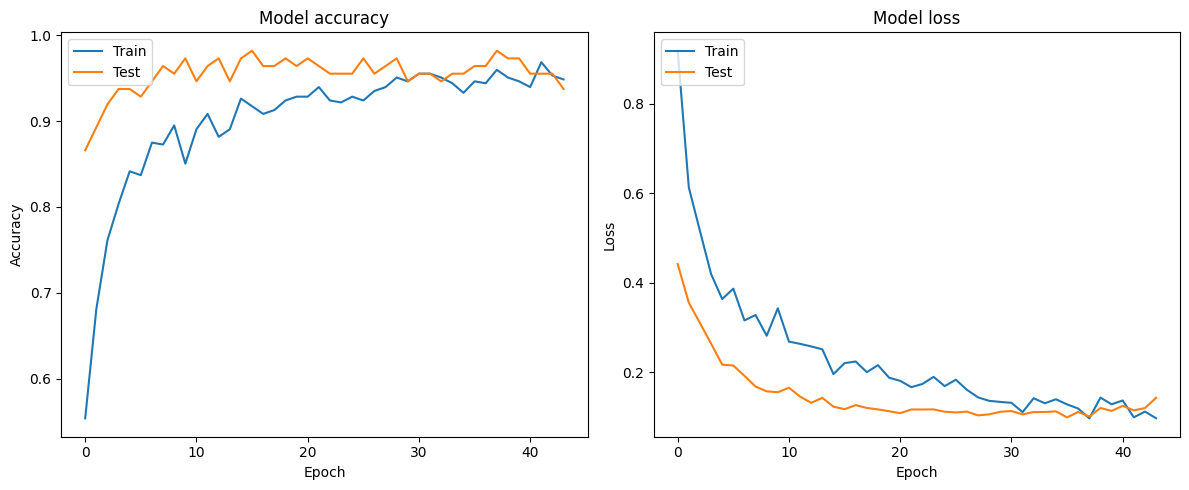

In [31]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.tight_layout()
plt.show()

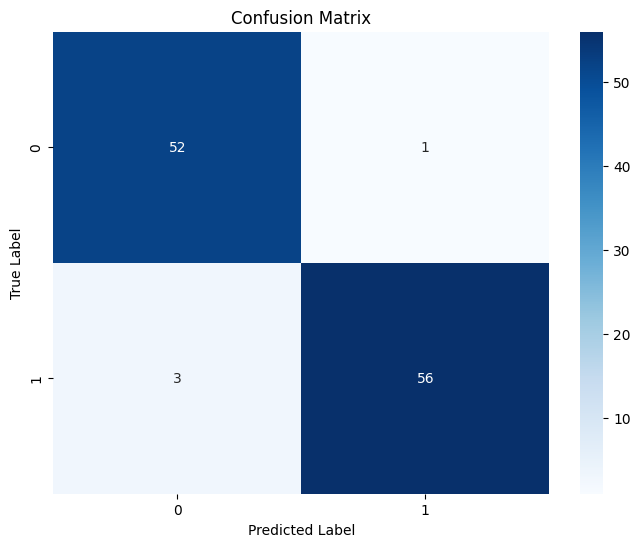

In [32]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_classes), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Generation 1: Best = 0.8750, Overall Best = 0.8750
Generation 2: Best = 0.8839, Overall Best = 0.8839
Generation 3: Best = 0.8839, Overall Best = 0.8839
Generation 4: Best = 0.8839, Overall Best = 0.8839
Generation 5: Best = 0.8929, Overall Best = 0.8929
Generation 6: Best = 0.9018, Overall Best = 0.9018
Generation 7: Best = 0.9018, Overall Best = 0.9018
Generation 8: Best = 0.9018, Overall Best = 0.9018
Generation 9: Best = 0.9018, Overall Best = 0.9018
Generation 10: Best = 0.9018, Overall Best = 0.9018

Genetic Algorithm Results:
Best Accuracy from GA: 0.9018
Selected Feature Indices: [ 1 16 20 22 25]
Selected Features:
Your current class level is
Q1
Q12
Q18
Conscientiousness


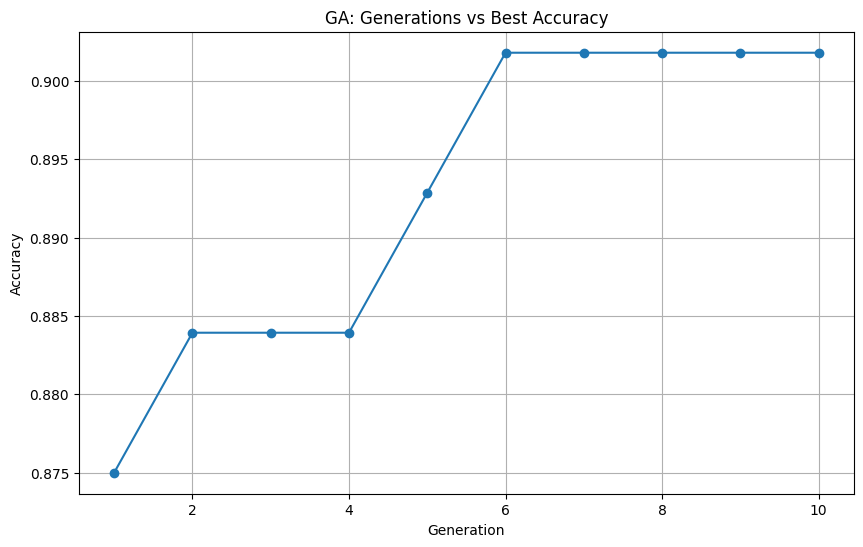

In [33]:
import numpy as np
import random
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# REPRODUCIBILITY
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# DATA (NO SMOTE)
X_ga = X
y_ga = y
feature_names_ga = df_normalized.drop(columns=["stress_label"]).columns

X_train_ga, X_test_ga, y_train_ga, y_test_ga = train_test_split(
    X_ga, y_ga,
    test_size=0.2,
    stratify=y_ga,
    random_state=42
)

# GA PARAMETERS
POP_SIZE = 20
GENERATIONS = 10
MUTATION_RATE = 0.2
NUM_FEATURES = X_ga.shape[1]
SELECT_K = 5

# CREATE INDIVIDUAL
def create_individual():
    individual = np.zeros(NUM_FEATURES, dtype=int)
    selected = np.random.choice(NUM_FEATURES, SELECT_K, replace=False)
    individual[selected] = 1
    return individual

population = [create_individual() for _ in range(POP_SIZE)]

# FITNESS CACHE
fitness_cache = {}

def fitness(individual):
    key = tuple(individual)
    if key in fitness_cache:
        return fitness_cache[key]

    selected_idx = np.where(individual == 1)[0]
    if len(selected_idx) == 0:
        return 0

    X_train_sel = X_train_ga.iloc[:, selected_idx]
    X_test_sel = X_test_ga.iloc[:, selected_idx]

    # FAST + STABLE ANN
    model = Sequential([
        tf.keras.Input(shape=(X_train_sel.shape[1],)),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train_sel, y_train_ga,
        epochs=8,
        batch_size=16,
        verbose=0
    )

    y_pred = model.predict(X_test_sel, verbose=0)
    y_pred_classes = (y_pred > 0.5).astype(int)

    acc = accuracy_score(y_test_ga, y_pred_classes)
    fitness_cache[key] = acc

    return acc

# SELECTION (TOURNAMENT)
def select(population, scores):
    idx = np.random.choice(len(population), 3, replace=False)
    best = idx[np.argmax([scores[i] for i in idx])]
    return population[best]

# CROSSOVER
def crossover(p1, p2):
    point = random.randint(1, NUM_FEATURES - 1)
    child = np.concatenate([p1[:point], p2[point:]])

    # enforce exactly SELECT_K features
    while np.sum(child) > SELECT_K:
        ones = np.where(child == 1)[0]
        child[np.random.choice(ones)] = 0

    while np.sum(child) < SELECT_K:
        zeros = np.where(child == 0)[0]
        child[np.random.choice(zeros)] = 1

    return child

# MUTATION
def mutate(individual):
    if random.random() < MUTATION_RATE:
        ones = np.where(individual == 1)[0]
        zeros = np.where(individual == 0)[0]
        if len(ones) > 0 and len(zeros) > 0:
            individual[np.random.choice(ones)] = 0
            individual[np.random.choice(zeros)] = 1
    return individual

# GA LOOP
best_individual_ga = None
best_score_ga = 0
generations_accuracy = []

for gen in range(GENERATIONS):
    scores = [fitness(ind) for ind in population]

    # ELITISM (keep best)
    best_idx = np.argmax(scores)
    elite = population[best_idx]

    current_best = scores[best_idx]
    generations_accuracy.append(current_best)

    if current_best > best_score_ga:
        best_score_ga = current_best
        best_individual_ga = elite

    new_population = [elite]

    while len(new_population) < POP_SIZE:
        p1 = select(population, scores)
        p2 = select(population, scores)
        child = crossover(p1, p2)
        child = mutate(child)
        new_population.append(child)

    population = new_population

    print(f"Generation {gen+1}: Best = {current_best:.4f}, Overall Best = {best_score_ga:.4f}")

# RESULTS
selected_indices_ga = np.where(best_individual_ga == 1)[0]
selected_features_ga = feature_names_ga[selected_indices_ga]

print("\nGenetic Algorithm Results:")
print(f"Best Accuracy from GA: {best_score_ga:.4f}")
print("Selected Feature Indices:", selected_indices_ga)
print("Selected Features:")
for f in selected_features_ga:
    print(f)

# PLOT
plt.figure(figsize=(10, 6))
plt.plot(range(1, GENERATIONS + 1), generations_accuracy, marker='o')
plt.title('GA: Generations vs Best Accuracy')
plt.xlabel('Generation')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

Training ANN with 5 GA-selected features...
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5826 - loss: 0.7085 - val_accuracy: 0.7857 - val_loss: 0.5742 - learning_rate: 5.0000e-04
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6272 - loss: 0.6267 - val_accuracy: 0.8214 - val_loss: 0.5209 - learning_rate: 5.0000e-04
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6875 - loss: 0.5886 - val_accuracy: 0.8304 - val_loss: 0.4777 - learning_rate: 5.0000e-04
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7076 - loss: 0.5761 - val_accuracy: 0.8571 - val_loss: 0.4442 - learning_rate: 5.0000e-04
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7232 - loss: 0.5579 - val_accuracy: 0.8929 - val_loss: 0.4209 - learning_rate: 5.0000e-04
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7411 - loss: 0.5341 - val_accuracy: 0.8839 - val_loss: 0.4032 - learning_rate: 5.0000e-04
Epoch 7/100
28/28 ━━━━━━━

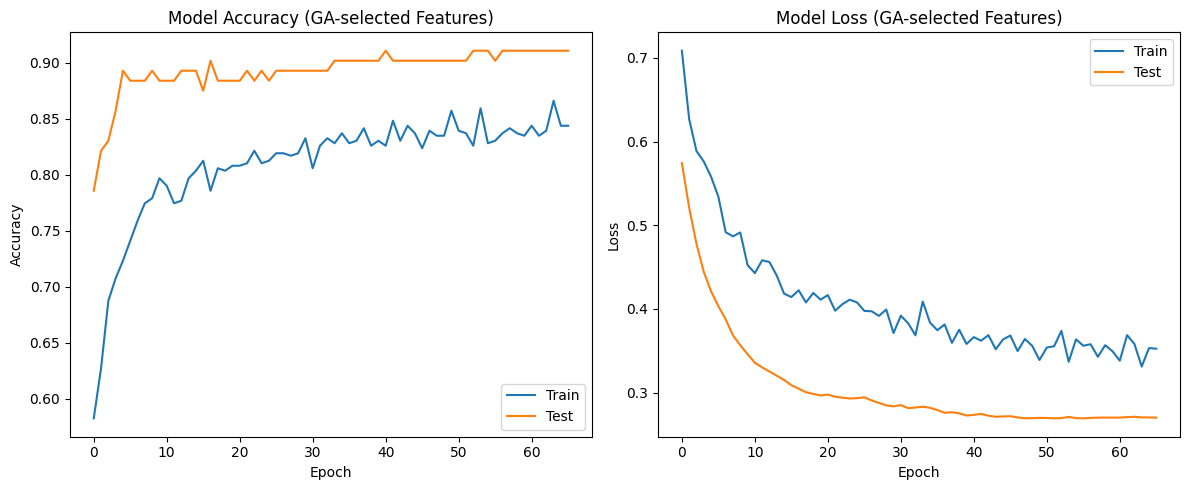

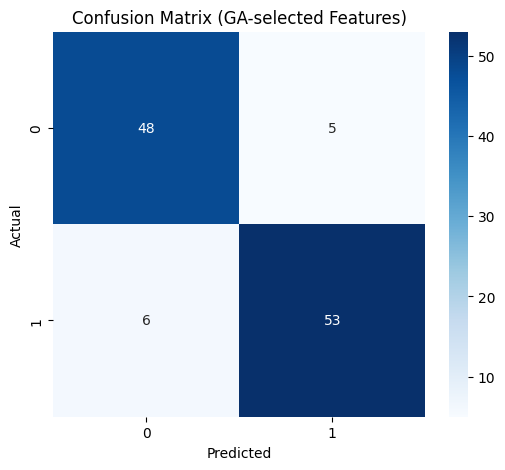

In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# USE ORIGINAL DATA
X_selected = X.iloc[:, selected_indices_ga]
y_selected = y

# TRAIN-TEST SPLIT
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected, y_selected,
    test_size=0.2,
    stratify=y_selected,
    random_state=42
)

# MODEL (IMPROVED FOR BINARY)
model_ga_features = Sequential([
    tf.keras.Input(shape=(X_train_selected.shape[1],)),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

model_ga_features.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# CALLBACKS
early_stop_ga = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    verbose=1
)

print(f"Training ANN with {len(selected_indices_ga)} GA-selected features...")

# TRAINING
history_ga = model_ga_features.fit(
    X_train_selected, y_train_selected,
    validation_data=(X_test_selected, y_test_selected),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop_ga, lr_scheduler],
    verbose=1
)

# EVALUATION
loss_ga, accuracy_ga = model_ga_features.evaluate(X_test_selected, y_test_selected, verbose=0)
print(f"\nFinal Test Accuracy (GA-selected features): {accuracy_ga:.4f}")

# PREDICTION (WITH THRESHOLD)
y_pred_prob_ga = model_ga_features.predict(X_test_selected)
threshold = 0.5
y_pred_classes_ga = (y_pred_prob_ga > threshold).astype(int)

# METRICS
print("\nClassification Report (GA-selected features):")
print(classification_report(y_test_selected, y_pred_classes_ga))

print("Confusion Matrix (GA-selected features):")
cm = confusion_matrix(y_test_selected, y_pred_classes_ga)
print(cm)

# PLOTS
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_ga.history['accuracy'])
plt.plot(history_ga.history['val_accuracy'])
plt.title('Model Accuracy (GA-selected Features)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'])

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_ga.history['loss'])
plt.plot(history_ga.history['val_loss'])
plt.title('Model Loss (GA-selected Features)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Test'])

plt.tight_layout()
plt.show()

# Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (GA-selected Features)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [35]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_selected, y)

weights = model.coef_[0]

for f, w in zip(selected_features_ga, weights):
    print(f"{f}: {w}")

Your current class level is: 0.011317300607700458
Q1: -1.0701412224914104
Q12: -1.7096436580791838
Q18: -1.2030143158220816
Conscientiousness: 0.08650895793322955


Accuracy: 0.8303571428571429

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.84      0.83       267
           1       0.85      0.82      0.83       293

    accuracy                           0.83       560
   macro avg       0.83      0.83      0.83       560
weighted avg       0.83      0.83      0.83       560


Threshold Tuning:

Threshold 5 → Accuracy: 0.8393
Threshold 5.5 → Accuracy: 0.8304
Threshold 6 → Accuracy: 0.8304
Threshold 6.5 → Accuracy: 0.8304


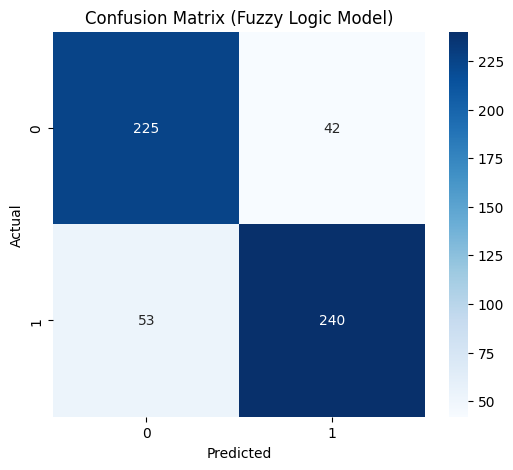

In [37]:
# ==============================
# 1. IMPORTS
# ==============================
!pip install scikit-fuzzy

import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# 2. DEFINE FUZZY VARIABLES
# ==============================

Q1 = ctrl.Antecedent(np.arange(0, 5, 1), 'Q1')
Q12 = ctrl.Antecedent(np.arange(0, 5, 1), 'Q12')
Q18 = ctrl.Antecedent(np.arange(0, 5, 1), 'Q18')

stress = ctrl.Consequent(np.arange(0, 11, 1), 'stress')

# ==============================
# 3. MEMBERSHIP FUNCTIONS (IMPROVED)
# ==============================

def add_membership(var):
    var['low'] = fuzz.trimf(var.universe, [0, 0, 2])
    var['medium'] = fuzz.trimf(var.universe, [1, 2, 3])
    var['high'] = fuzz.trimf(var.universe, [2, 4, 4])

for v in [Q1, Q12, Q18]:
    add_membership(v)

# 🔥 Adjusted output (balanced)
stress['low'] = fuzz.trimf(stress.universe, [0, 0, 6])
stress['medium'] = fuzz.trimf(stress.universe, [4, 5, 6])
stress['high'] = fuzz.trimf(stress.universe, [6, 10, 10])

# ==============================
# 4. FUZZY RULES (BALANCED)
# ==============================

rules = [

    # 🔴 HIGH STRESS rules (controlled)
    ctrl.Rule(Q12['low'], stress['high']),
    ctrl.Rule(Q18['low'], stress['high']),
    ctrl.Rule(Q1['low'], stress['high']),
    ctrl.Rule(Q12['low'] & Q18['low'], stress['high']),

    # 🟢 LOW STRESS rules (strengthened)
    ctrl.Rule(Q12['high'], stress['low']),
    ctrl.Rule(Q18['high'], stress['low']),
    ctrl.Rule(Q1['high'], stress['low']),

    ctrl.Rule(Q12['high'] & Q18['high'], stress['low']),
    ctrl.Rule(Q12['high'] & Q1['high'], stress['low']),
    ctrl.Rule(Q18['high'] & Q1['high'], stress['low']),

    # 🟡 MEDIUM rules (buffer zone)
    ctrl.Rule(Q1['medium'] & Q12['medium'], stress['medium']),
    ctrl.Rule(Q12['medium'] & Q18['medium'], stress['medium']),
    ctrl.Rule(Q1['medium'] & Q18['medium'], stress['medium']),

    # 🔧 Conflict balancing (VERY IMPORTANT)
    ctrl.Rule(Q12['low'] & Q18['high'], stress['medium']),
    ctrl.Rule(Q12['low'] & Q1['high'], stress['medium']),
    ctrl.Rule(Q18['low'] & Q1['high'], stress['medium']),
]

# ==============================
# 5. BUILD SYSTEM
# ==============================

system = ctrl.ControlSystem(rules)

# ==============================
# 6. PREDICTION FUNCTION (FIXED)
# ==============================

def fuzzy_predict(X):
    preds = []
    outputs = []

    for i in range(len(X)):
        sim = ctrl.ControlSystemSimulation(system)  # ✅ fresh sim each time

        try:
            sim.input['Q1'] = X.iloc[i]['Q1']
            sim.input['Q12'] = X.iloc[i]['Q12']
            sim.input['Q18'] = X.iloc[i]['Q18']

            sim.compute()
            output = sim.output['stress']
            outputs.append(output)

        except:
            output = 0
            outputs.append(output)

    # 🔥 Tune threshold
    threshold = 6  # changed from 5 → reduces bias toward HIGH

    for o in outputs:
        preds.append(1 if o > threshold else 0)

    return np.array(preds), np.array(outputs)

# ==============================
# 7. RUN PREDICTION
# ==============================

X_fuzzy = X_selected[['Q1', 'Q12', 'Q18']]
y_pred, raw_outputs = fuzzy_predict(X_fuzzy)

# ==============================
# 8. EVALUATION
# ==============================

print("Accuracy:", accuracy_score(y, y_pred))
print("\nClassification Report:\n")
print(classification_report(y, y_pred))

# ==============================
# 9. OPTIONAL: THRESHOLD TUNING
# ==============================

print("\nThreshold Tuning:\n")
for t in [5, 5.5, 6, 6.5]:
    preds = (raw_outputs > t).astype(int)
    print(f"Threshold {t} \u2192 Accuracy: {accuracy_score(y, preds):.4f}")

# ==============================
# 10. CONFUSION MATRIX VISUALIZATION
# ==============================

cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Fuzzy Logic Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()